In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from src.config import DADOS_ORIGINAIS, DADOS_LIMPOS
from src.graficos import PALETTE

sns.set_theme(palette="bright")

https://www.kaggle.com/datasets/ashrafkhan94/mammography-breast-cancer

In [2]:
df = pd.read_csv(
    DADOS_ORIGINAIS,
    names=[
        "area",
        "cinza",
        "perimetro",
        "ruido",
        "contraste",
        "formato",
        "target",
    ],
)

df.head()

,area,cinza,perimetro,ruido,contraste,formato,target
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,'-1'
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,'-1'
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,'-1'
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,'-1'
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,'-1'


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11183 entries, 0 to 11182
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       11183 non-null  float64
 1   cinza      11183 non-null  float64
 2   perimetro  11183 non-null  float64
 3   ruido      11183 non-null  float64
 4   contraste  11183 non-null  float64
 5   formato    11183 non-null  float64
 6   target     11183 non-null  str    
dtypes: float64(6), str(1)
memory usage: 655.1 KB


In [4]:
le = LabelEncoder()

df["target"] = le.fit_transform(df["target"])

df.head()

,area,cinza,perimetro,ruido,contraste,formato,target
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11183 entries, 0 to 11182
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       11183 non-null  float64
 1   cinza      11183 non-null  float64
 2   perimetro  11183 non-null  float64
 3   ruido      11183 non-null  float64
 4   contraste  11183 non-null  float64
 5   formato    11183 non-null  float64
 6   target     11183 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 611.7 KB


In [6]:
with pd.option_context("display.float_format", "{:.3f}".format):
    display(df.describe())

,area,cinza,perimetro,ruido,contraste,formato,target
count,11183.000,11183.000,11183.000,11183.000,11183.000,11183.000,11183.000
mean,0.000,0.000,0.000,-0.000,-0.000,0.000,0.023
std,1.000,1.000,1.000,1.000,1.000,1.000,0.151
min,-0.784,-0.470,-0.592,-0.860,-0.378,-0.946,0.000
25%,-0.784,-0.470,-0.592,-0.860,-0.378,-0.946,0.000
50%,-0.109,-0.395,-0.231,-0.860,-0.378,-0.946,0.000
75%,0.314,-0.076,0.220,0.820,-0.378,1.017,0.000
max,31.508,5.086,29.478,9.591,23.617,1.949,1.000


In [7]:
df["target"].value_counts()

target
0    10923
1      260
Name: count, dtype: int64

In [8]:
df["target"].value_counts(normalize=True)

target
0    0.97675
1    0.02325
Name: proportion, dtype: float64

In [9]:
df[df.duplicated()]

,area,cinza,perimetro,ruido,contraste,formato,target
11,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
16,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
19,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
23,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
24,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
...,...,...,...,...,...,...,...
11151,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
11152,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
11153,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0
11155,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,0


In [10]:
df[df.duplicated()].query("target == 1")

,area,cinza,perimetro,ruido,contraste,formato,target
3354,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1
7817,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1
7828,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1
8934,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1
10061,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1
11161,-0.784415,-0.470195,-0.591631,-0.859553,-0.377866,-0.945723,1


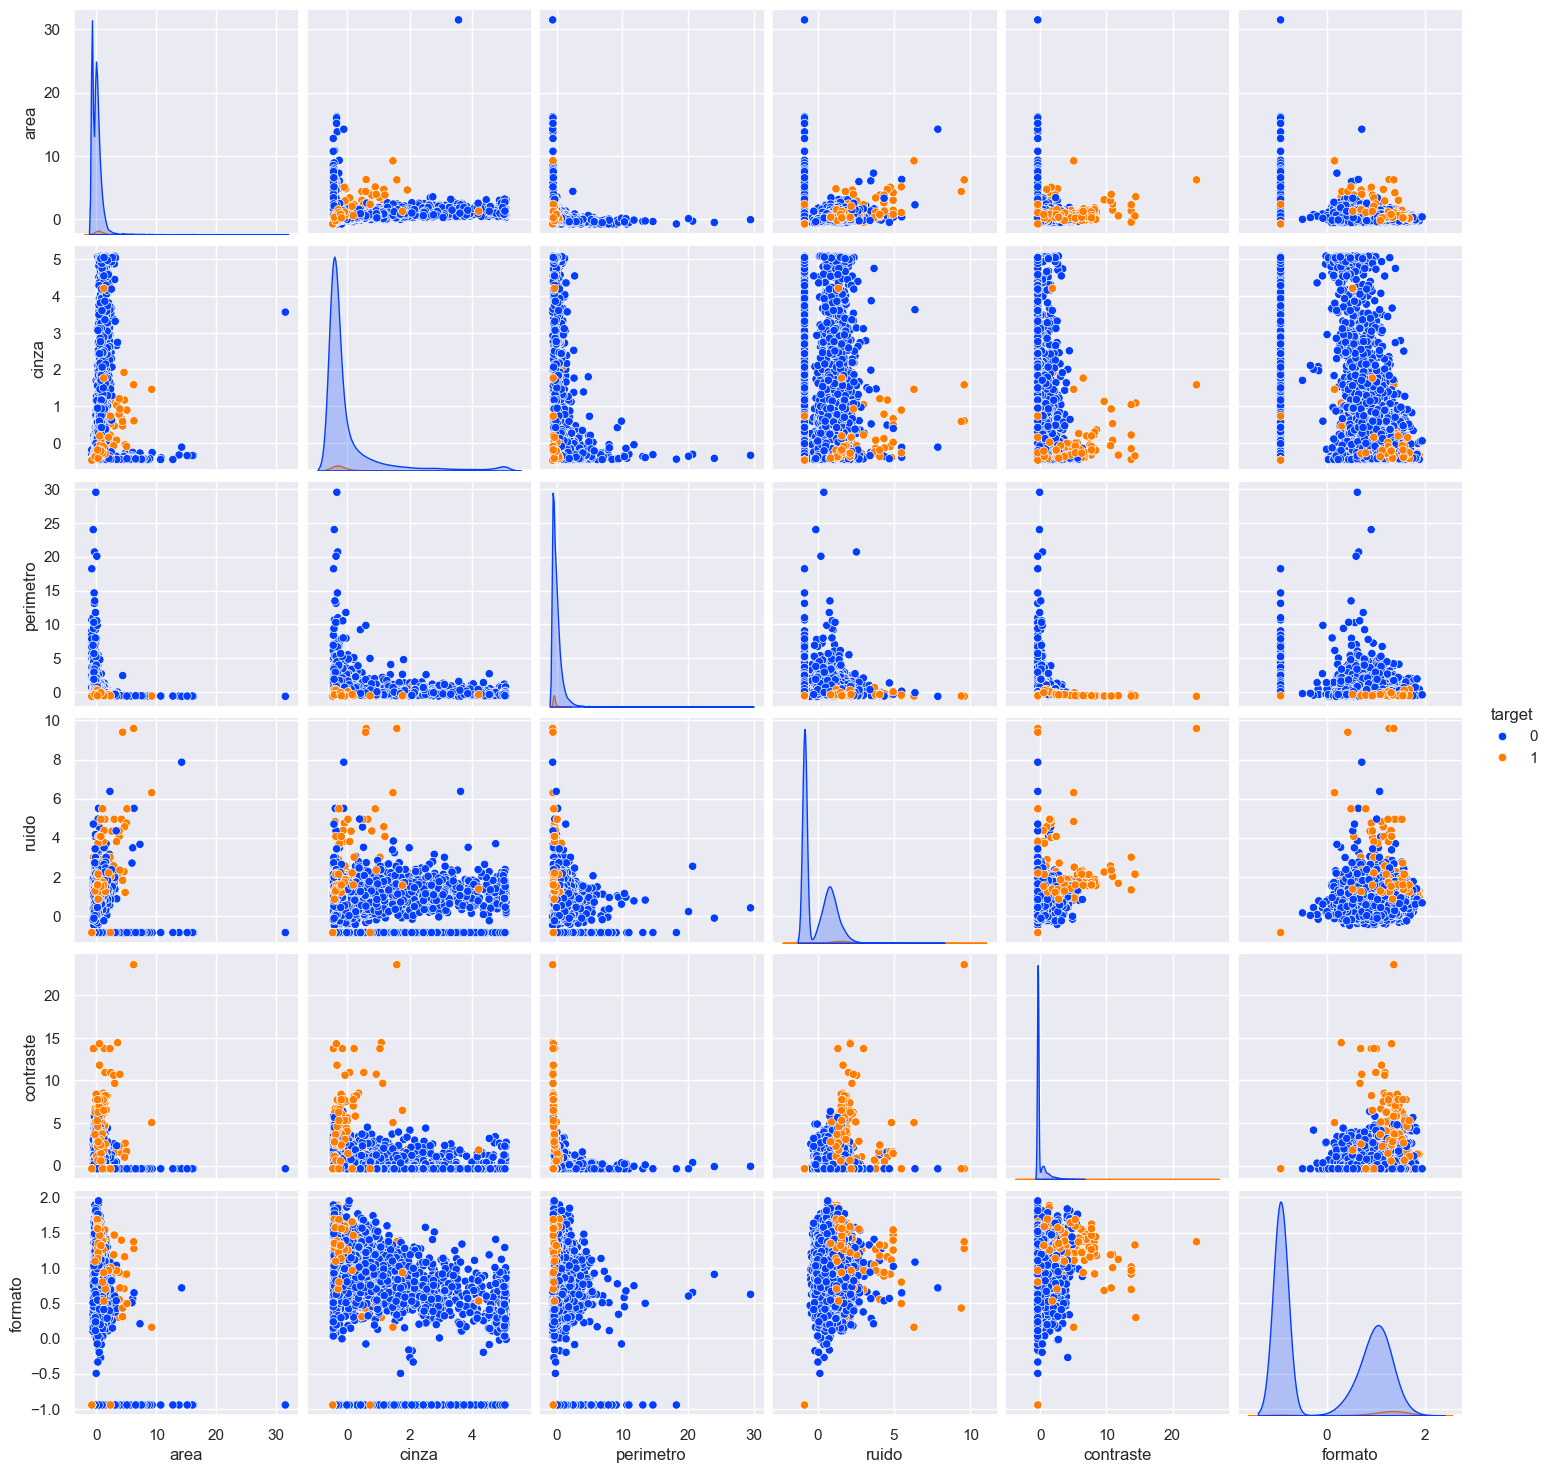

In [11]:
sns.pairplot(df, hue="target")

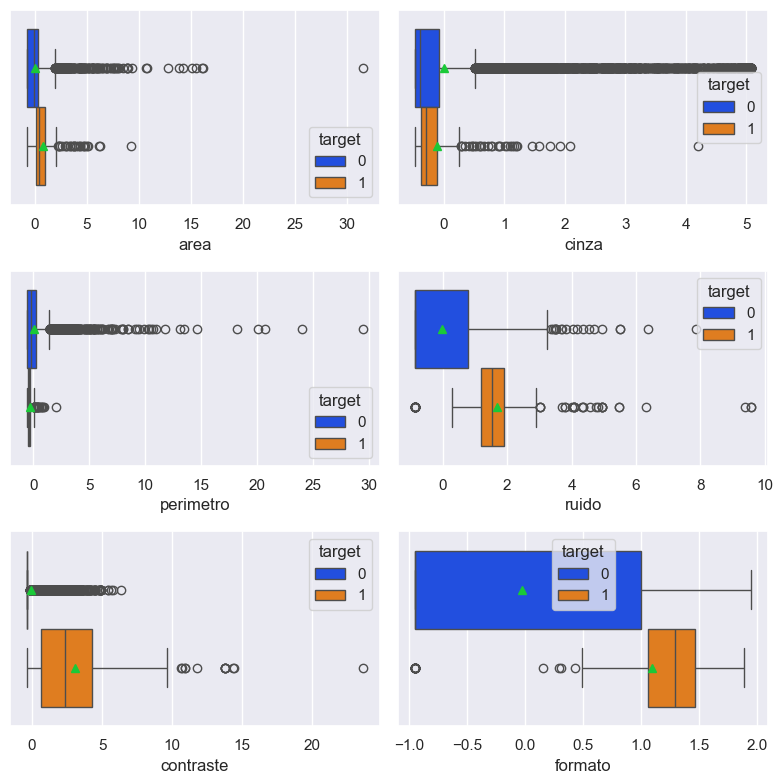

In [12]:
fig, axs = plt.subplots(3, 2, figsize=(8, 8))

for ax, coluna in zip(axs.flatten(), df.iloc[:, :-1].columns):
    sns.boxplot(x=coluna, ax=ax, data=df, showmeans=True, hue="target")

plt.tight_layout()
plt.show()

In [13]:
df.to_parquet(DADOS_LIMPOS, index=False)